In [ ]:
pip install opendatasets

In [ ]:
import os
import matplotlib
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/c/rossmann-store-sales')

Skipping, found downloaded files in "./rossmann-store-sales" (use force=True to force download)


In [ ]:
os.listdir('rossmann-store-sales')

['sample_submission.csv', 'test.csv', 'train.csv', 'store.csv']

In [ ]:
ross_df = pd.read_csv('./rossmann-store-sales/train.csv', low_memory=False)

In [ ]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [ ]:
store_df = pd.read_csv('rossmann-store-sales/store.csv')

In [ ]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
merged_df = ross_df.merge(store_df,how ='left',on = 'Store')
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
test_df = pd.read_csv('rossmann-store-sales/test.csv')
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [ ]:
merged_test_df = test_df.merge(store_df, how='left', on='Store')

In [ ]:
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [ ]:
merged_test_df.columns

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [ ]:
merged_test_df = merged_test_df.drop(columns=['Id'])

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [ ]:
round(merged_df.describe(),2)

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1017209.00,1017209.0,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1014567.00,693861.00,693861.00,1017209.0,509178.00,509178.00
mean,558.43,4.0,5773.82,633.15,0.83,0.38,0.18,5430.09,7.22,2008.69,0.5,23.27,2011.75
std,321.91,2.0,3849.93,464.41,0.38,0.49,0.38,7715.32,3.21,5.99,0.5,14.10,1.66
min,1.00,1.0,0.00,0.00,0.00,0.00,0.00,20.00,1.00,1900.00,0.0,1.00,2009.00
25%,280.00,2.0,3727.00,405.00,1.00,0.00,0.00,710.00,4.00,2006.00,0.0,13.00,2011.00
50%,558.00,4.0,5744.00,609.00,1.00,0.00,0.00,2330.00,8.00,2010.00,1.0,22.00,2012.00
75%,838.00,6.0,7856.00,837.00,1.00,1.00,0.00,6890.00,10.00,2013.00,1.0,37.00,2013.00
max,1115.00,7.0,41551.00,7388.00,1.00,1.00,1.00,75860.00,12.00,2015.00,1.0,50.00,2015.00


In [ ]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])


In [ ]:
merged_test_df['Date'] = pd.to_datetime(merged_test_df['Date'])

In [ ]:
merged_df['Date'].min(),merged_df['Date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [ ]:
merged_test_df['Date'].min(),merged_test_df['Date'].max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

In [ ]:
merged_df.nunique()

,0
Store,1115
DayOfWeek,7
Date,942
Sales,21734
Customers,4086
Open,2
Promo,2
StateHoliday,4
SchoolHoliday,2
StoreType,4


<Axes: xlabel='Sales', ylabel='Count'>

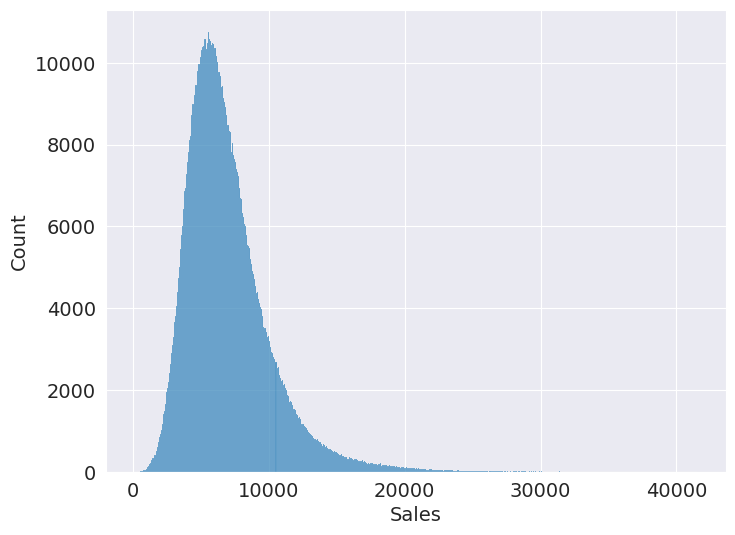

In [ ]:
plt.figure(figsize=(8,6))
data = merged_df[merged_df['Sales'] > 0]
sns.histplot(data = data,x ='Sales')

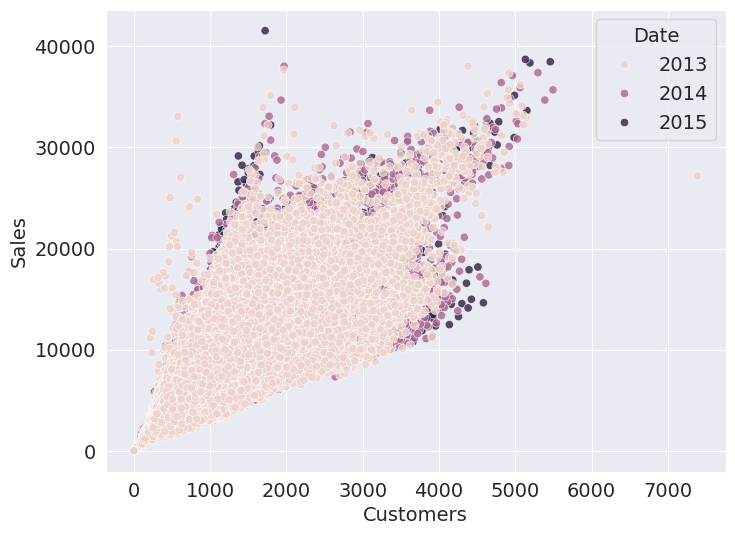

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=merged_df,x='Customers',y='Sales',alpha =0.8,hue =merged_df.Date.dt.year)
plt.show()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

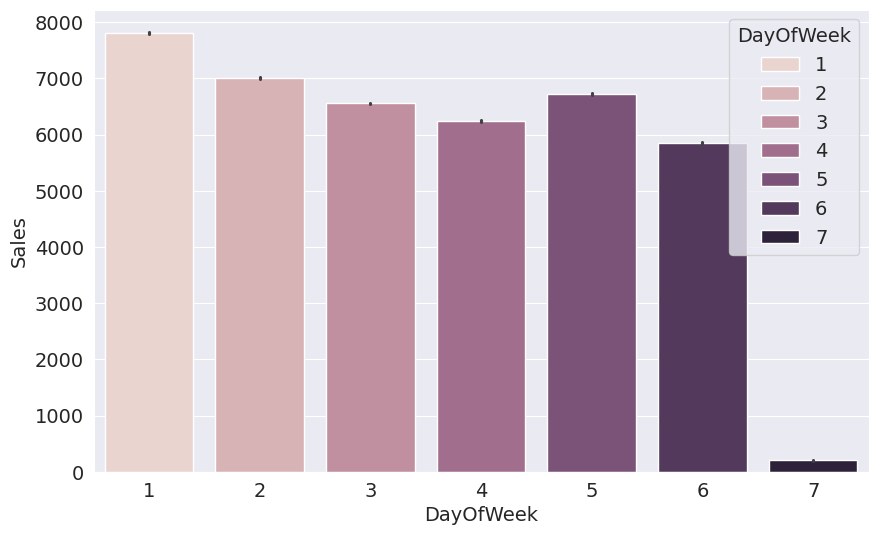

In [ ]:
sns.barplot(data=merged_df, x='DayOfWeek', y='Sales',hue ='DayOfWeek')

In [ ]:
merged_df.corr(numeric_only=True)['Sales'].sort_values(ascending=False)


,Sales
Sales,1.000000
Customers,0.894711
Open,0.678472
Promo,0.452345
SchoolHoliday,0.085124
Promo2SinceWeek,0.059558
CompetitionOpenSinceYear,0.012659
Store,0.005126
CompetitionDistance,-0.019229
Promo2SinceYear,-0.021127


In [ ]:
merged_df['Day'] = merged_df['Date'].dt.day
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Year'] = merged_df['Date'].dt.year

In [ ]:
merged_test_df['Day'] = merged_test_df['Date'].dt.day
merged_test_df['Month'] = merged_test_df['Date'].dt.month
merged_test_df['Year'] = merged_test_df['Date'].dt.year

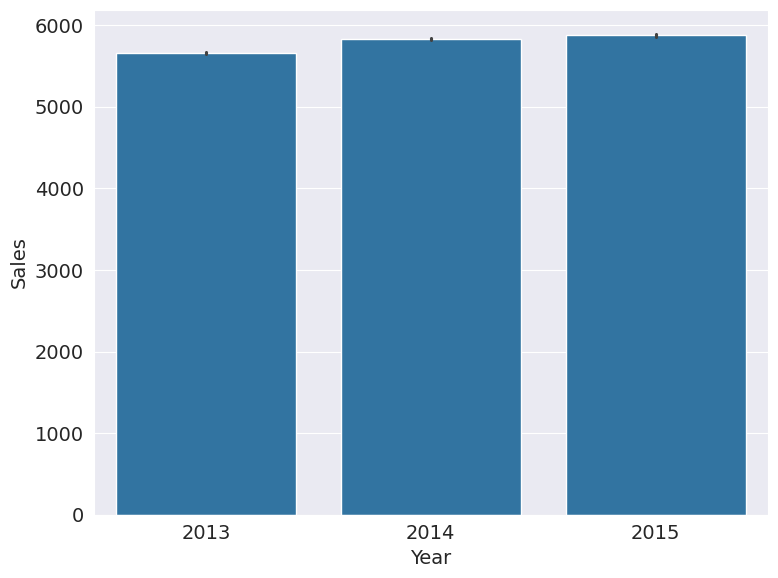

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(data = merged_df , x = 'Year',y = merged_df['Sales'])
plt.tight_layout()

In [ ]:
len(merged_df)

1017209

In [ ]:
train_size = int(.80 * len(merged_df))
train_size

813767

In [ ]:
sorted_df = merged_df.sort_values('Date')
train_df,val_df = sorted_df[:train_size],sorted_df[train_size:]

In [ ]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,...,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec",1,1,2013
1016473,379,2,2013-01-01,0,0,0,0,a,1,d,...,6630.0,NaN,NaN,0,NaN,NaN,NaN,1,1,2013
1016472,378,2,2013-01-01,0,0,0,0,a,1,a,...,2140.0,8.0,2012.0,0,NaN,NaN,NaN,1,1,2013
1016471,377,2,2013-01-01,0,0,0,0,a,1,a,...,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov",1,1,2013
1016470,376,2,2013-01-01,0,0,0,0,a,1,a,...,160.0,8.0,2012.0,0,NaN,NaN,NaN,1,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203899,970,5,2015-01-30,3952,413,1,1,0,0,a,...,910.0,12.0,2014.0,1,37.0,2009.0,"Jan,Apr,Jul,Oct",30,1,2015
203898,969,5,2015-01-30,3883,619,1,1,0,0,a,...,600.0,11.0,1999.0,1,10.0,2013.0,"Jan,Apr,Jul,Oct",30,1,2015
203897,968,5,2015-01-30,8711,987,1,1,0,0,c,...,1190.0,NaN,NaN,0,NaN,NaN,NaN,30,1,2015
203896,967,5,2015-01-30,9196,925,1,1,0,0,a,...,3560.0,9.0,2013.0,1,36.0,2013.0,"Jan,Apr,Jul,Oct",30,1,2015


In [ ]:
train_df.Date.min(),train_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-01-30 00:00:00'))

In [ ]:
val_df.Date.min(),val_df.Date.max()

(Timestamp('2015-01-30 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [ ]:
merged_df.corr(numeric_only=True)['Sales'].sort_values(ascending=False)

,Sales
Sales,1.000000
Customers,0.894711
Open,0.678472
Promo,0.452345
SchoolHoliday,0.085124
Promo2SinceWeek,0.059558
Month,0.048768
Year,0.023519
CompetitionOpenSinceYear,0.012659
Store,0.005126


In [ ]:
input_cols =['Open','Promo','SchoolHoliday','Promo2SinceWeek','Month','Year','CompetitionOpenSinceYear','Store','Day','Assortment']

In [ ]:
target_cols = 'Sales'

In [ ]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_cols].copy()

In [ ]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_cols].copy()

In [ ]:
test_inputs = merged_test_df[input_cols].copy()
# Test data does not have targets

In [ ]:
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge,SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [ ]:
train_inputs

,Open,Promo,SchoolHoliday,Promo2SinceWeek,Month,Year,CompetitionOpenSinceYear,Store,Day,Assortment
1017208,0,0,1,22.0,1,2013,NaN,1115,1,c
1016473,0,0,1,NaN,1,2013,NaN,379,1,a
1016472,0,0,1,NaN,1,2013,2012.0,378,1,c
1016471,0,0,1,18.0,1,2013,2010.0,377,1,c
1016470,0,0,1,NaN,1,2013,2012.0,376,1,a
...,...,...,...,...,...,...,...,...,...,...
203899,1,1,0,37.0,1,2015,2014.0,970,30,a
203898,1,1,0,10.0,1,2015,1999.0,969,30,c
203897,1,1,0,NaN,1,2015,NaN,968,30,a
203896,1,1,0,36.0,1,2015,2013.0,967,30,c


In [ ]:
# Convert 'Assortment' column to category dtype for all datasets
train_inputs['Assortment'] = train_inputs['Assortment'].astype('category')
val_inputs['Assortment'] = val_inputs['Assortment'].astype('category')
test_inputs['Assortment'] = test_inputs['Assortment'].astype('category')

# Fill NaN values in numerical columns with 0 for all datasets
train_inputs['Promo2SinceWeek'] = train_inputs['Promo2SinceWeek'].fillna(0)
train_inputs['CompetitionOpenSinceYear'] = train_inputs['CompetitionOpenSinceYear'].fillna(0)

val_inputs['Promo2SinceWeek'] = val_inputs['Promo2SinceWeek'].fillna(0)
val_inputs['CompetitionOpenSinceYear'] = val_inputs['CompetitionOpenSinceYear'].fillna(0)

test_inputs['Promo2SinceWeek'] = test_inputs['Promo2SinceWeek'].fillna(0)
test_inputs['CompetitionOpenSinceYear'] = test_inputs['CompetitionOpenSinceYear'].fillna(0)

xgb =XGBRegressor(
    n_estimators=200,
    learning_rate=0.25,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    enable_categorical=True)

xgb.fit(train_inputs,train_targets)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.25, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
xgb.score(train_inputs,train_targets)

0.8868100643157959

In [ ]:
xgb.score(val_inputs,val_targets)

0.8392084240913391

In [ ]:
'''
import numpy as np
from scipy.stats import randint
# Removed unused DecisionTreeClassifier import
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor # Ensure XGBRegressor is imported

param_dist = {
    "max_depth": randint(3,10), # Adjusted for typical XGBoost depth range
    "learning_rate": np.linspace(0.01, 0.5, 10), # More appropriate range for learning rate
    "subsample": [0.6,0.7,0.8,0.9], # XGBoost specific parameter
    "colsample_bytree": np.linspace(0.6, 1.0, 5), # XGBoost specific parameter
    "n_estimator": np.arange(100,201) # XGBoost specific parameter, replaces min_samples_split
}

# Initialize XGBRegressor with enable_categorical=True
model = XGBRegressor(min_child_weight=2,enable_categorical=True, random_state=42, n_jobs=-1, objective='reg:squarederror')
model_cv = RandomizedSearchCV(model, param_dist, cv=5, random_state=42, verbose=1)
model_cv.fit(train_inputs, train_targets)

print("Tuned  Parameters: {}".format(model_cv.best_params_))
print("Best score is {}".format(model_cv.best_score_))
'''
'''
Tuned  Parameters: {'colsample_bytree': np.float64(0.9), 'learning_rate': np.float64(0.3911111111111111), 'max_depth': 7, 'n_estimator': np.int64(120), 'subsample': 0.8}
Best score is 0.8510708332061767
'''

"\nTuned  Parameters: {'colsample_bytree': np.float64(0.9), 'learning_rate': np.float64(0.3911111111111111), 'max_depth': 7, 'n_estimator': np.int64(120), 'subsample': 0.8}\nBest score is 0.8510708332061767\n"

In [ ]:
import numpy as np
from scipy.stats import randint
# Removed unused DecisionTreeClassifier import
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor # Ensure XGBRegressor is imported

param_dist = {
    "max_depth": [6, 7], # Provide a list of discrete values for GridSearchCV
    "learning_rate": np.linspace(0.05, 0.55, 10), # More appropriate range for learning rate
    "subsample": [0.8,0.9], # XGBoost specific parameter
    "colsample_bytree": [0.9], # XGBoost specific parameter
    "min_child_weight": [1, 2, 3], # Provide a list of discrete values
    "n_estimators": np.arange(100,200) # Provide a list of discrete values for GridSearchCV
}

# Initialize XGBRegressor with enable_categorical=True
model = XGBRegressor(enable_categorical=True, random_state=42, n_jobs=-1, objective='reg:squarederror')
model_cv = GridSearchCV(model, param_dist, cv=5, verbose=1)
model_cv.fit(train_inputs, train_targets)

print("Tuned  Parameters: {}".format(model_cv.best_params_))
print("Best score is {}".format(model_cv.best_score_))

Fitting 5 folds for each of 12000 candidates, totalling 60000 fits
